## EXPLORATORY DATA ANALYSIS

```text
----------------------------------------------------------------------------------
EDA Notebook Flow
│
├── Dataset Overview
├── Missing Values
├── Duplicates
├── Class Distribution
├── Sample Images
│
Data Preprocessing
│
├── Image Dimension Analysis
├── Image Quality Analysis
│      ├── Pixel Intensity Analysis
│      ├── Brightness Analysis
│      ├── Contrast Analysis
│      ├── RGB Analysis
│      ├── Edge Density Analysis
│      ├── Blur Analysis
│      └── Noise Analysis
│
├── AI-Specific Analysis
│      ├── Sharpness
│      ├── Entropy
│      ├── LBP Visualization
│      └── FFT Visualization
│
Feature Engineering
│
├── LBP Features
├── FFT Features
│
Feature Selection (To be continued in Python File)
│
Model Building
--------------------------------------------------------------------------------------------
```

### Import Libraries

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from skimage.feature import local_binary_pattern
from scipy.ndimage import gaussian_filter
from skimage.filters import sobel
from skimage.measure import shannon_entropy

SEED = 42

### Data Collection

In [2]:
import os
import zipfile

DATASET = "birdy654/cifake-real-and-ai-generated-synthetic-images"

if not os.path.exists("dataset"):
    os.system(
        f"kaggle datasets download -d {DATASET}"
    )

    with zipfile.ZipFile(
        "cifake-real-and-ai-generated-synthetic-images.zip",
        "r"
    ) as zip_ref:

        zip_ref.extractall("dataset")

print("Dataset Downlaoded")

Dataset Downlaoded


### Data Loading

In [3]:
data = []

for split in ["train", "test"]:
    for label in ["REAL", "FAKE"]:
        folder = os.path.join(
            "dataset",
            split,
            label
        )
        for img in os.listdir(folder):

            data.append([
                os.path.join(folder, img),
                label,
                split
            ])

df = pd.DataFrame(
    data,
    columns=[
        "filepath",
        "label",
        "split"
    ]
)
print("Dataset Dataframe")
print(df.shape)
df.head()

Dataset Dataframe
(101738, 3)


,filepath,label,split
0,dataset\train\REAL\0000 (10).jpg,REAL,train
1,dataset\train\REAL\0000 (2).jpg,REAL,train
2,dataset\train\REAL\0000 (3).jpg,REAL,train
3,dataset\train\REAL\0000 (4).jpg,REAL,train
4,dataset\train\REAL\0000 (5).jpg,REAL,train


### Dataset Overview

In [4]:
print(df["label"].value_counts())
print("\n")
print(df["split"].value_counts())

label
FAKE    60000
REAL    41738
Name: count, dtype: int64


split
train    81738
test     20000
Name: count, dtype: int64


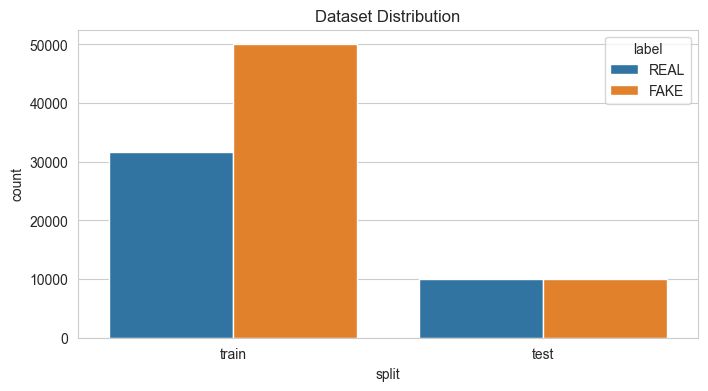

In [5]:
# Class Distribution
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="split",
    hue="label"
)

plt.title("Dataset Distribution")
plt.show()

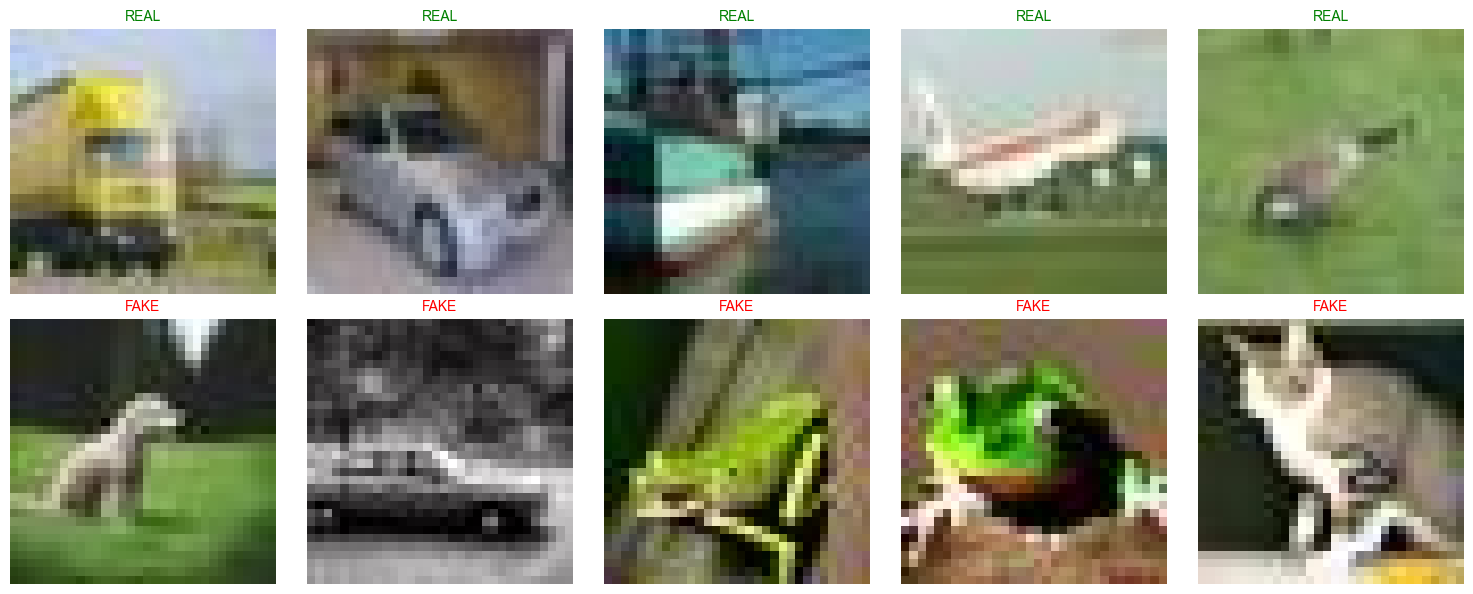

In [6]:
fig, ax = plt.subplots(
    2,
    5,
    figsize=(15,6)
)

real_df = df[df["label"]=="REAL"].sample(5)
fake_df = df[df["label"]=="FAKE"].sample(5)

for i, (_, row) in enumerate(real_df.iterrows()):

    img = cv2.imread(row["filepath"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax[0,i].imshow(img)
    ax[0,i].set_title("REAL", color="green", fontsize=10)
    ax[0,i].axis("off")

for i, (_, row) in enumerate(fake_df.iterrows()):

    img = cv2.imread(row["filepath"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax[1,i].imshow(img)
    ax[1,i].set_title("FAKE", color="red", fontsize=10)
    ax[1,i].axis("off")

plt.tight_layout()
plt.show()

Path: dataset\test\FAKE\256 (7).jpg
Split: test
Label: FAKE
Image Size: (32, 32)
Image Mode: RGB
Image Format: JPEG


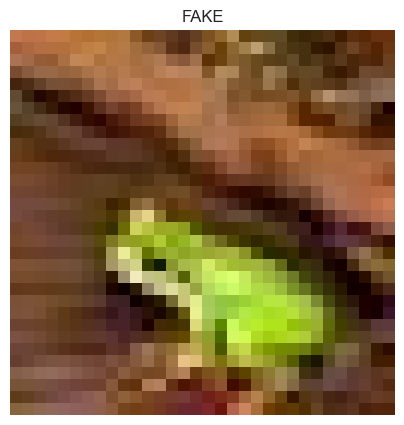

In [7]:
# Basic Sample Image Configurations

sample = df.sample(1).iloc[0]

img = Image.open(sample["filepath"])
print("Path:", sample["filepath"])
print("Split:", sample["split"])
print("Label:", sample["label"])
print("Image Size:", img.size)
print("Image Mode:", img.mode)
print("Image Format:", img.format)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(sample["label"])
plt.axis("off")
plt.show()



### Data Preprocessing

In [8]:
# Checking for Missing Images

missing_images = []

for path in tqdm(df["filepath"]):
    if not os.path.exists(path):
        missing_images.append(path)

print(
    "Missing Image Files:",
    len(missing_images)
)

100%|██████████| 101738/101738 [02:13<00:00, 760.20it/s] 


Missing Image Files: 0


In [9]:
# Checking for Corrupted Images

corrupted = []

for path in tqdm(df["filepath"]):
    try:
        img = cv2.imread(path)
        if img is None:
            corrupted.append(path)
    except:
        corrupted.append(path)
print(
    "Corrupted Images:",
    len(corrupted)
)

100%|██████████| 101738/101738 [06:25<00:00, 264.18it/s]


Corrupted Images: 1


In [10]:
# Checking for Duplicate Image Files

duplicate_files = df["filepath"].duplicated().sum()
print(
    "Duplicate Images Files:",
    duplicate_files
)

Duplicate Images Files: 0


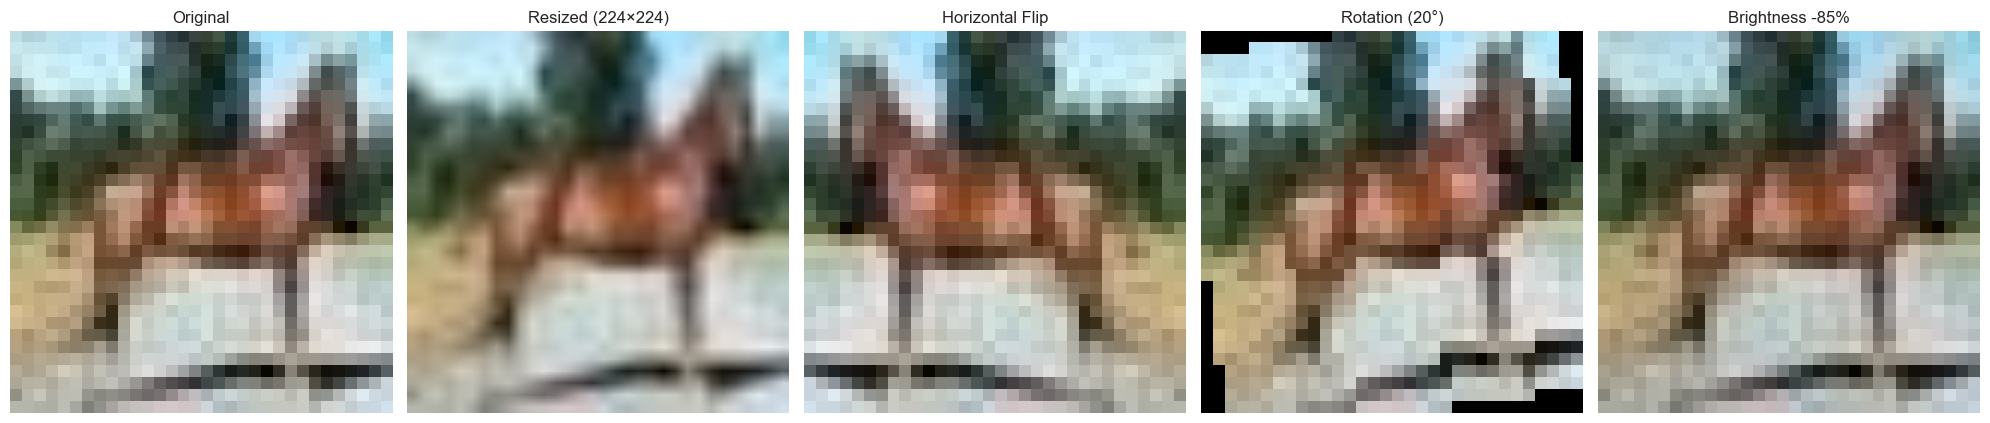

In [11]:
# Data Augmentation - resize, flip, rotation, brightness adjustment on a sample image

sample_path = df["filepath"].sample(
    1,
    random_state=42
).iloc[0]

# Read Image
img = cv2.imread(sample_path)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

original = img.copy()

# Convert to PIL
pil_img = Image.fromarray(original)

# Resize
resize_transform = transforms.Resize(
    (224,224)
)

resized_img = np.array(
    resize_transform(pil_img)
)

# Horizontal Flip
flip_transform = transforms.RandomHorizontalFlip(
    p=1
)

flip_img = np.array(
    flip_transform(pil_img)
)

# Rotation
rotation_transform = transforms.RandomRotation(
    degrees=20
)

rotated_img = np.array(
    rotation_transform(pil_img)
)

# Brightness Adjustment
brightness_transform = transforms.ColorJitter(
    brightness=0.5
)

bright_img = np.array(
    brightness_transform(pil_img)
)

# Plot Results
fig, axes = plt.subplots(
    1,
    5,
    figsize=(20,5)
)

axes[0].imshow(original)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(resized_img)
axes[1].set_title("Resized (224×224)")
axes[1].axis("off")

axes[2].imshow(flip_img)
axes[2].set_title("Horizontal Flip")
axes[2].axis("off")

axes[3].imshow(rotated_img)
axes[3].set_title("Rotation (20°)")
axes[3].axis("off")

axes[4].imshow(bright_img)
axes[4].set_title("Brightness -85%")
axes[4].axis("off")

plt.tight_layout()
plt.show()

### Feature ExtractionEngineering & Extraction

In [12]:
# Image Dimension Analysis

dimension_data = []

for _, row in tqdm(
    df.iterrows(),
    total=len(df)
):

    path = row["filepath"]
    label = row["label"]
    split = row["split"]

    try:

        img = cv2.imread(path)

        # Image Dimensions
        height, width = img.shape[:2]

        # Aspect Ratio
        aspect_ratio = width / height

        # Resolution
        resolution = f"{width}x{height}"

        dimension_data.append([
            path,
            label,
            split,
            width,
            height,
            aspect_ratio,
            resolution
        ])

    except Exception:
        continue


dimension_df = pd.DataFrame(
    dimension_data,
    columns=[
        "filepath",
        "label",
        "split",
        "width",
        "height",
        "aspect_ratio",
        "resolution"
    ]
)

print(
    "Dimension Analysis Shape:",
    dimension_df.shape
)

dimension_df.head()

100%|██████████| 101738/101738 [11:07<00:00, 152.50it/s]


Dimension Analysis Shape: (101737, 7)


,filepath,label,split,width,height,aspect_ratio,resolution
0,dataset\train\REAL\0000 (10).jpg,REAL,train,32,32,1.0,32x32
1,dataset\train\REAL\0000 (2).jpg,REAL,train,32,32,1.0,32x32
2,dataset\train\REAL\0000 (3).jpg,REAL,train,32,32,1.0,32x32
3,dataset\train\REAL\0000 (4).jpg,REAL,train,32,32,1.0,32x32
4,dataset\train\REAL\0000 (5).jpg,REAL,train,32,32,1.0,32x32


In [13]:
dimension_df[
    [
        "width",
        "height",
        "aspect_ratio",
        "resolution"
    ]
].describe()

,width,height,aspect_ratio
count,101737.0,101737.0,101737.0
mean,32.0,32.0,1.0
std,0.0,0.0,0.0
min,32.0,32.0,1.0
25%,32.0,32.0,1.0
50%,32.0,32.0,1.0
75%,32.0,32.0,1.0
max,32.0,32.0,1.0


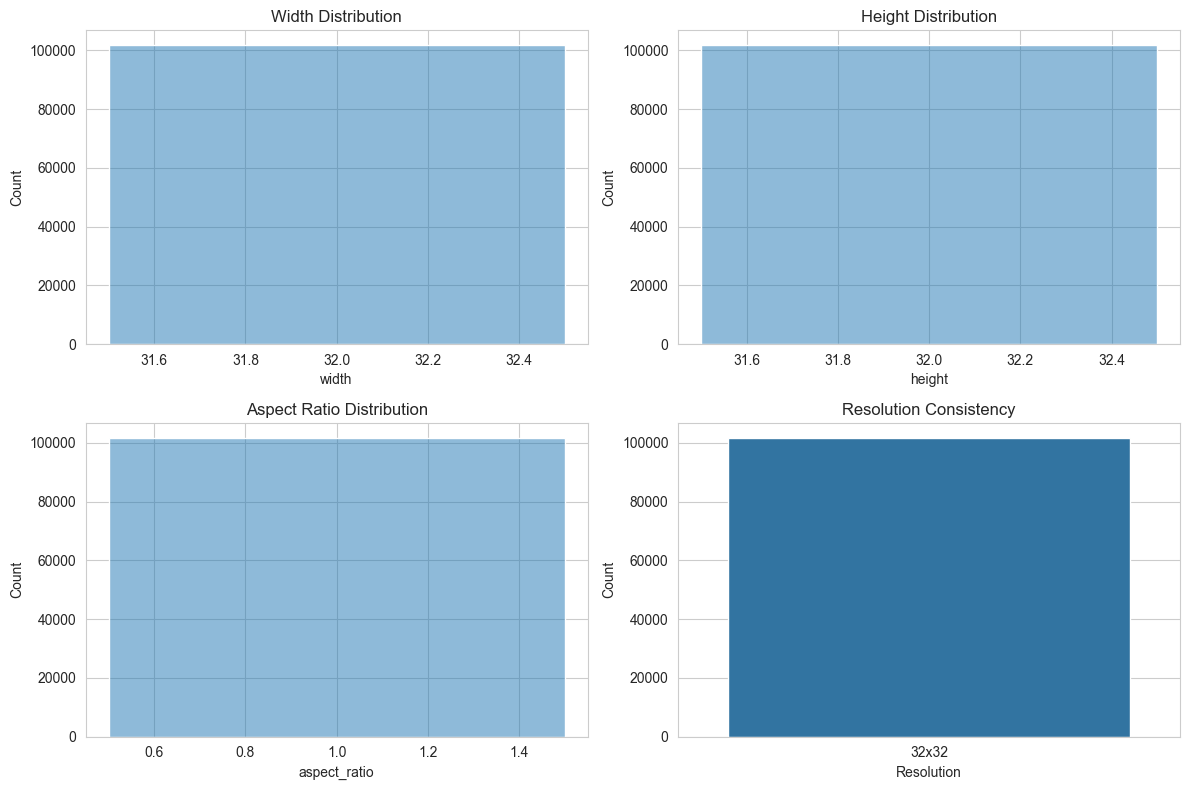

In [14]:
# Image Dimension Distribution

fig, ax = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

# Width Distribution
sns.histplot(
    dimension_df["width"],
    kde=True,
    ax=ax[0,0]
)

ax[0,0].set_title(
    "Width Distribution"
)

# Height Distribution
sns.histplot(
    dimension_df["height"],
    kde=True,
    ax=ax[0,1]
)

ax[0,1].set_title(
    "Height Distribution"
)

# Aspect Ratio Distribution
sns.histplot(
    dimension_df["aspect_ratio"],
    kde=True,
    ax=ax[1,0]
)

ax[1,0].set_title(
    "Aspect Ratio Distribution"
)

# Resolution Consistency
resolution_counts = (
    dimension_df["resolution"]
    .value_counts()
)

sns.barplot(
    x=resolution_counts.index,
    y=resolution_counts.values,
    ax=ax[1,1]
)

ax[1,1].set_title(
    "Resolution Consistency"
)

ax[1,1].set_xlabel(
    "Resolution"
)

ax[1,1].set_ylabel(
    "Count"
)

plt.tight_layout()

plt.show()

In [15]:
# Image Quality Analysis
# Brightness,Contrast,Edge Density,Noise Variance,RGB Statistics

image_quality_data = []

for _, row in tqdm(
    df.iterrows(),
    total=len(df)
):

    path = row["filepath"]
    label = row["label"]
    split = row["split"]

    try:

        img = cv2.imread(path)

        rgb = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        gray = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY
        )

        # Brightness
        brightness = np.mean(gray)

        # Contrast
        contrast = np.std(gray)

        # Edge Density
        edges = cv2.Canny(
            gray,
            100,
            200
        )

        edge_density = (
            np.sum(edges > 0)
            / edges.size
        )

        # Blur Score
        blur_score = cv2.Laplacian(
            gray,
            cv2.CV_64F
        ).var()

        # Noise Variance
        noise_variance = blur_score

        # RGB Statistics
        r_mean = rgb[:,:,0].mean()
        g_mean = rgb[:,:,1].mean()
        b_mean = rgb[:,:,2].mean()

        image_quality_data.append([
            path,
            label,
            split,
            brightness,
            contrast,
            edge_density,
            blur_score,
            noise_variance,
            r_mean,
            g_mean,
            b_mean
        ])

    except:
        continue


quality_df = pd.DataFrame(
    image_quality_data,
    columns=[
        "filepath",
        "label",
        "split",
        "brightness",
        "contrast",
        "edge_density",
        "blur_score",
        "noise_variance",
        "red_mean",
        "green_mean",
        "blue_mean"
    ]
)

quality_df.head()

100%|██████████| 101738/101738 [13:23<00:00, 126.61it/s]


,filepath,label,split,brightness,contrast,edge_density,blur_score,noise_variance,red_mean,green_mean,blue_mean
0,dataset\train\REAL\0000 (10).jpg,REAL,train,130.299805,59.999812,0.333008,5764.751891,5764.751891,130.342773,130.325195,130.274414
1,dataset\train\REAL\0000 (2).jpg,REAL,train,100.883789,56.763362,0.202148,2937.161742,2937.161742,92.188477,102.393555,115.953125
2,dataset\train\REAL\0000 (3).jpg,REAL,train,135.495117,43.073724,0.324219,2404.180663,2404.180663,120.540039,152.875977,85.214844
3,dataset\train\REAL\0000 (4).jpg,REAL,train,72.375000,55.989257,0.189453,2035.814834,2035.814834,77.915039,71.681641,61.402344
4,dataset\train\REAL\0000 (5).jpg,REAL,train,85.330078,32.691599,0.208984,1370.308646,1370.308646,99.888672,83.250000,57.906250


In [16]:
quality_df[
    [
        "brightness",
        "contrast",
        "edge_density",
        "blur_score",
        "noise_variance",
        "red_mean",
        "green_mean",
        "blue_mean"
    ]
].describe()

,brightness,contrast,edge_density,blur_score,noise_variance,red_mean,green_mean,blue_mean
count,101737.000000,101737.000000,101737.000000,101737.000000,101737.000000,101737.000000,101737.000000,101737.000000
mean,116.566866,50.748727,0.203803,3219.850616,3219.850616,119.568674,117.214210,105.272990
std,26.116341,14.780582,0.068653,1994.404877,1994.404877,26.314494,27.076587,40.888929
min,17.221680,6.160937,0.000000,29.693172,29.693172,5.637695,13.659180,5.488281
25%,99.124023,40.117885,0.155273,1744.781006,1744.781006,102.835938,99.083984,76.107422
50%,115.195312,50.900690,0.207031,2828.223629,2828.223629,118.465820,115.833008,102.500977
75%,131.835938,61.240891,0.253906,4279.006637,4279.006637,134.562500,133.424805,130.810547
max,252.010742,113.545657,0.420898,49851.765548,49851.765548,251.924805,252.459961,252.436523


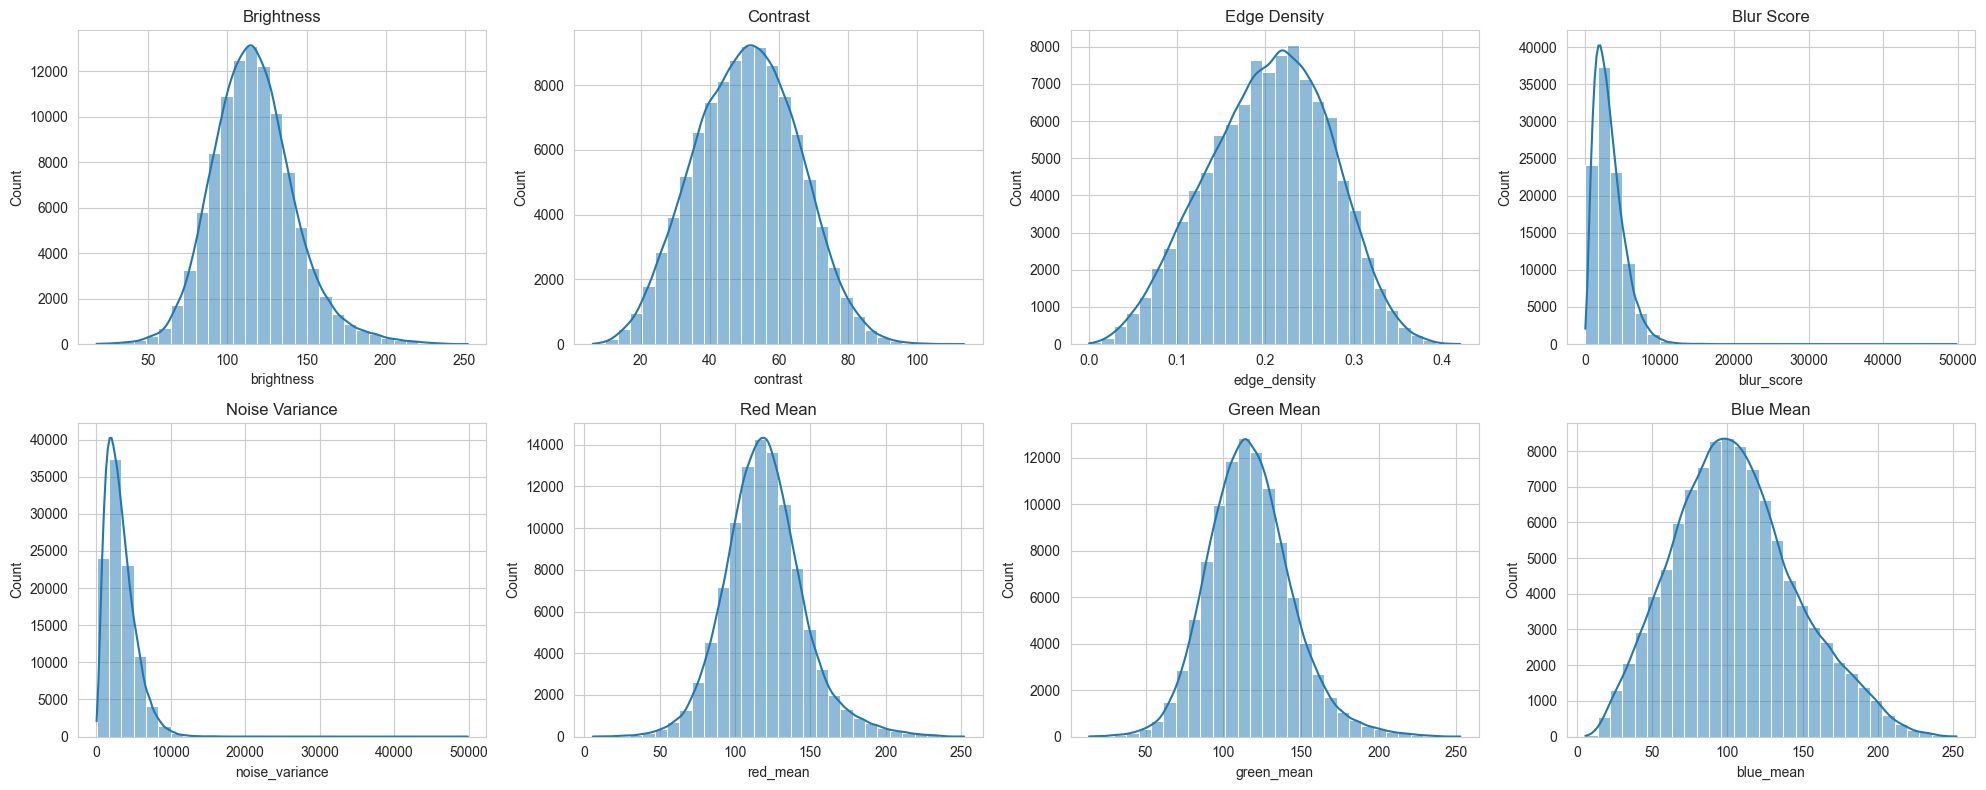

In [17]:
# Image Quality Distribution

features = [
    "brightness",
    "contrast",
    "edge_density",
    "blur_score",
    "noise_variance",
    "red_mean",
    "green_mean",
    "blue_mean"
]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(20,8)
)

for ax, feature in zip(
    axes.flatten(),
    features
):

    sns.histplot(
        quality_df[feature],
        bins=30,
        kde=True,
        ax=ax
    )

    ax.set_title(
        feature.replace("_"," ").title()
    )

plt.tight_layout()
plt.show()

In [ ]:
# AI-Image Specific Analysis
# blur score, sharpness score, exntropy analysis

ai_features = []

for _, row in tqdm(
    df.iterrows(),
    total=len(df)
):

    path = row["filepath"]
    label = row["label"]
    split = row["split"]

    try:

        img = cv2.imread(path)

        gray = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY
        )

        # Blur Score
        blur_score = cv2.Laplacian(
            gray,
            cv2.CV_64F
        ).var()

        # Sharpness Score
        sobel_x = cv2.Sobel(
            gray,
            cv2.CV_64F,
            1,
            0
        )

        sobel_y = cv2.Sobel(
            gray,
            cv2.CV_64F,
            0,
            1
        )

        sharpness_score = np.mean(
            np.sqrt(
                sobel_x**2 +
                sobel_y**2
            )
        )

        # Entropy Score
        entropy_score = shannon_entropy(
            gray
        )

        ai_features.append([
            path,
            label,
            split,
            blur_score,
            sharpness_score,
            entropy_score
        ])

    except:
        continue


ai_df = pd.DataFrame(
    ai_features,
    columns=[
        "filepath",
        "label",
        "split",
        "blur_score",
        "sharpness_score",
        "entropy_score"
    ]
)

ai_df.head()



 19%|█▉        | 19763/101738 [01:24<06:53, 198.08it/s]

In [ ]:
features = [
    "blur_score",
    "sharpness_score",
    "entropy_score"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,4)
)

for ax, feature in zip(
    axes,
    features
):

    sns.histplot(
        ai_df[feature],
        bins=30,
        kde=True,
        ax=ax
    )

    ax.set_title(
        feature.replace("_"," ").title()
    )

plt.tight_layout()
plt.show()

In [ ]:
pixel_means = []

for path in tqdm(df["filepath"]):

    img = cv2.imread(path)

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    pixel_means.append(
        gray.mean()
    )

df["pixel_mean"] = pixel_means

sns.boxplot(
    data=df,
    x="label",
    y="pixel_mean"
)

plt.title("Pixel Intensity Distribution")
plt.show()


In [ ]:
sns.boxplot(
    data=df,
    x="label",
    y="pixel_mean"
)

plt.title("Pixel Intensity Distribution")
plt.show()

In [ ]:
# Feature Engineering - LBP & FFT 

feature_data = []

for _, row in tqdm(
    df.iterrows(),
    total=len(df)
):

    path = row["filepath"]
    label = row["label"]

    try:

        # --------------------------------
        # Read Image
        # --------------------------------

        gray = cv2.imread(
            path,
            cv2.IMREAD_GRAYSCALE
        )

        # ==================================
        # LBP FEATURES
        # ==================================

        radius = 3

        n_points = 8 * radius

        lbp = local_binary_pattern(
            gray,
            n_points,
            radius,
            method="uniform"
        )

        lbp_hist, _ = np.histogram(
            lbp.ravel(),
            bins=np.arange(
                0,
                n_points + 3
            ),
            range=(
                0,
                n_points + 2
            )
        )

        lbp_hist = lbp_hist.astype(
            "float"
        )

        lbp_hist /= (
            lbp_hist.sum() + 1e-6
        )

        # ==================================
        # FFT FEATURES
        # ==================================

        fft = np.fft.fft2(
            gray
        )

        fft_shift = np.fft.fftshift(
            fft
        )

        magnitude = np.abs(
            fft_shift
        )

        fft_mean = magnitude.mean()

        fft_std = magnitude.std()

        fft_max = magnitude.max()

        fft_min = magnitude.min()

        # ==================================
        # FEATURE DICTIONARY
        # ==================================

        features = {}

        # LBP Features

        for i, value in enumerate(
            lbp_hist
        ):

            features[
                f"lbp_{i}"
            ] = value

        # FFT Features

        features[
            "fft_mean"
        ] = fft_mean

        features[
            "fft_std"
        ] = fft_std

        features[
            "fft_max"
        ] = fft_max

        features[
            "fft_min"
        ] = fft_min

        # Label

        features[
            "label"
        ] = label

        feature_data.append(
            features
        )

    except Exception:
        continue


# ==================================
# Create Feature DataFrame
# ==================================

feature_df = pd.DataFrame(
    feature_data
)

# Encode Target

feature_df["target"] = (
    feature_df["label"]
    .map({
        "REAL":0,
        "FAKE":1
    })
)

print(
    "Feature Dataset Shape:",
    feature_df.shape
)

feature_df.head()

In [ ]:
lbp_cols = [
    col
    for col in feature_df.columns
    if col.startswith("lbp_")
]

lbp_summary = (
    feature_df
    .groupby("label")[lbp_cols]
    .mean()
)

plt.figure(
    figsize=(15,6)
)

for label in lbp_summary.index:

    plt.plot(
        lbp_summary.columns,
        lbp_summary.loc[label],
        marker="o",
        label=label
    )

plt.title(
    "Average LBP Histogram (REAL vs FAKE)"
)

plt.xticks(
    rotation=90
)

plt.legend()

plt.show()

In [ ]:
fft_features = [
    "fft_mean",
    "fft_std",
    "fft_max",
    "fft_min"
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

for ax, feature in zip(
    axes.flatten(),
    fft_features
):

    sns.boxplot(
        data=feature_df,
        x="label",
        y=feature,
        ax=ax
    )

    ax.set_title(
        feature.upper()
    )

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# Select Sample Images
# ==========================================

sample_real = df[
    df["label"]=="REAL"
]["filepath"].iloc[0]

sample_fake = df[
    df["label"]=="FAKE"
]["filepath"].iloc[0]

# ==========================================
# Read Images
# ==========================================

real_rgb = cv2.cvtColor(
    cv2.imread(sample_real),
    cv2.COLOR_BGR2RGB
)

fake_rgb = cv2.cvtColor(
    cv2.imread(sample_fake),
    cv2.COLOR_BGR2RGB
)

real_gray = cv2.imread(
    sample_real,
    cv2.IMREAD_GRAYSCALE
)

fake_gray = cv2.imread(
    sample_fake,
    cv2.IMREAD_GRAYSCALE
)

# ==========================================
# FFT Function
# ==========================================

def fft_spectrum(img):

    fft = np.fft.fft2(img)

    fft_shift = np.fft.fftshift(
        fft
    )

    magnitude = np.log(
        np.abs(
            fft_shift
        ) + 1
    )

    return magnitude

# ==========================================
# FFT Images
# ==========================================

real_fft = fft_spectrum(real_gray)
fake_fft = fft_spectrum(fake_gray)

# ==========================================
# Plot
# ==========================================

fig, ax = plt.subplots(
    1,
    4,
    figsize=(18,5)
)

# REAL IMAGE
ax[0].imshow(real_rgb)
ax[0].set_title("REAL Image")
ax[0].axis("off")

# REAL FFT
im1 = ax[1].imshow(
    real_fft,
    cmap="inferno"
)

ax[1].set_title(
    f"REAL FFT\nMin={real_fft.min():.2f} Max={real_fft.max():.2f}"
)

ax[1].axis("off")

plt.colorbar(
    im1,
    ax=ax[1],
    fraction=0.046
)

# FAKE IMAGE
ax[2].imshow(fake_rgb)
ax[2].set_title("FAKE Image")
ax[2].axis("off")

# FAKE FFT
im2 = ax[3].imshow(
    fake_fft,
    cmap="inferno"
)

ax[3].set_title(
    f"FAKE FFT\nMin={fake_fft.min():.2f} Max={fake_fft.max():.2f}"
)

ax[3].axis("off")

plt.colorbar(
    im2,
    ax=ax[3],
    fraction=0.046
)

plt.tight_layout()

plt.show()

In [ ]:
# =====================================
# Random REAL and FAKE Sample
# =====================================

real_path = df[
    df["label"]=="REAL"
]["filepath"].sample(
    1,
    random_state=42
).iloc[0]

fake_path = df[
    df["label"]=="FAKE"
]["filepath"].sample(
    1,
    random_state=42
).iloc[0]

# =====================================
# Feature Extraction Function
# =====================================

def extract_visual_features(path):

    img = cv2.imread(path)

    img_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    # ---------------------
    # LBP
    # ---------------------

    radius = 3
    points = radius * 8

    lbp = local_binary_pattern(
        gray,
        points,
        radius,
        method="uniform"
    )

    # ---------------------
    # Noise Residual
    # ---------------------

    blurred = gaussian_filter(
        gray,
        sigma=1
    )

    noise = cv2.absdiff(
        gray,
        blurred.astype(
            np.uint8
        )
    )

    # ---------------------
    # Edge Map
    # ---------------------

    edges = cv2.Canny(
        gray,
        100,
        200
    )

    # ---------------------
    # FFT
    # ---------------------

    fft = np.fft.fft2(
        gray
    )

    fft_shift = np.fft.fftshift(
        fft
    )

    magnitude = np.log(
        np.abs(
            fft_shift
        ) + 1
    )

    # ---------------------
    # Sharpness Map
    # ---------------------

    sharpness = sobel(
        gray
    )

    return (
        img_rgb,
        gray,
        lbp,
        noise,
        edges,
        magnitude,
        sharpness
    )

# =====================================
# Extract Features
# =====================================

real_features = extract_visual_features(
    real_path
)

fake_features = extract_visual_features(
    fake_path
)

# =====================================
# Plot Dashboard
# =====================================

titles = [
    "Image",
    "Gray",
    "LBP",
    "Noise Residual",
    "Edges",
    "FFT",
    "Sharpness"
]

fig, axes = plt.subplots(
    2,
    7,
    figsize=(24,8)
)

for i in range(7):

    cmap = None

    if i > 0:
        cmap = "inferno"

    axes[0,i].imshow(
        real_features[i],
        cmap=cmap
    )

    axes[0,i].set_title(
        f"REAL {titles[i]}"
    )

    axes[0,i].axis("off")

    axes[1,i].imshow(
        fake_features[i],
        cmap=cmap
    )

    axes[1,i].set_title(
        f"FAKE {titles[i]}"
    )

    axes[1,i].axis("off")

plt.tight_layout()

plt.show()